In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('/home/asabele/Downloads/Documents/My Data Science Practise/Advertising.csv', index_col=0)

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (200, 4)

First 5 rows:
      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB
None

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.7

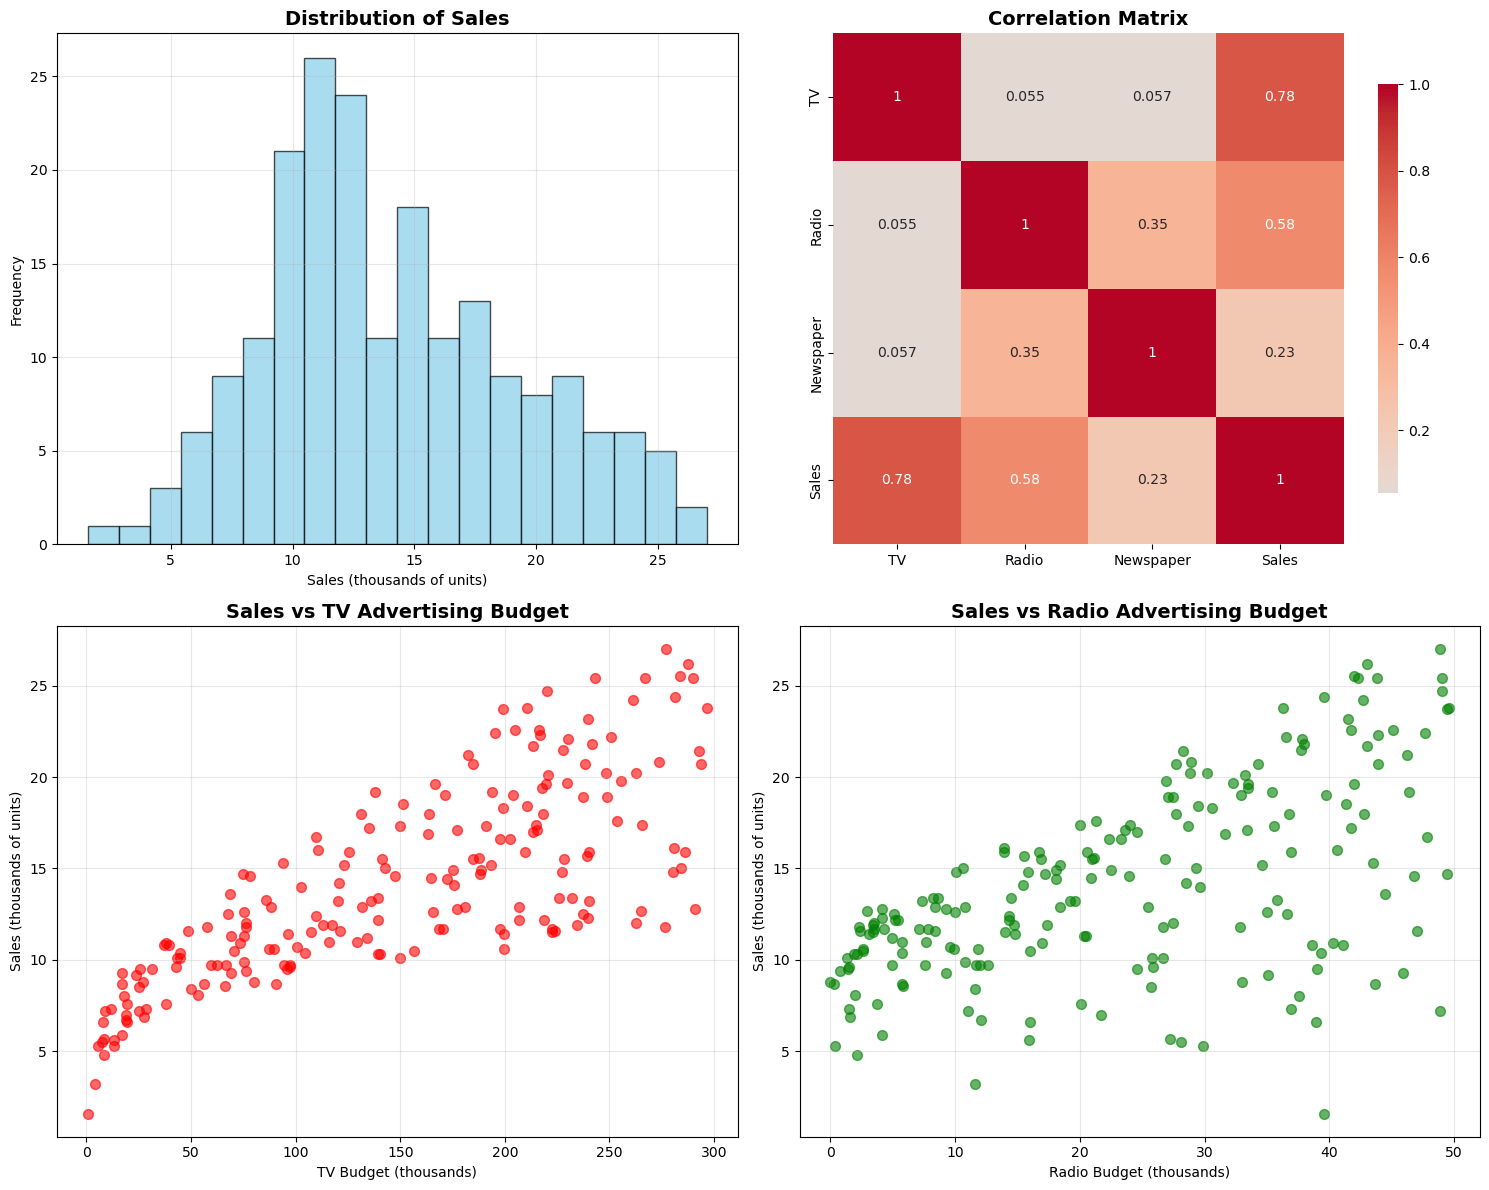

EDA visualizations saved!


In [15]:
df_clean = df.copy()
df_clean = df_clean.dropna()


#visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1.
axes[0, 0].hist(df_clean['Sales'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Sales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sales (thousands of units)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[0, 1], cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 3
axes[1, 0].scatter(df_clean['TV'], df_clean['Sales'], alpha=0.6, color='red', s=50)
axes[1, 0].set_title('Sales vs TV Advertising Budget', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('TV Budget (thousands)')
axes[1, 0].set_ylabel('Sales (thousands of units)')
axes[1, 0].grid(True, alpha=0.3)

# 4
axes[1, 1].scatter(df_clean['Radio'], df_clean['Sales'], alpha=0.6, color='green', s=50)
axes[1, 1].set_title('Sales vs Radio Advertising Budget', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Radio Budget (thousands)')
axes[1, 1].set_ylabel('Sales (thousands of units)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/asabele/Downloads/Documents/My Data Science Practise/sales_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA visualizations saved!")


In [16]:

# Prepare data for modeling
X = df_clean[['TV', 'Radio', 'Newspaper']]
y = df_clean['Sales']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

# Train and evaluate models
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'y_pred': y_pred_test
    }
    
    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")

# Feature importance for Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)


Training set size: 160
Test set size: 40

Linear Regression:
  Train R²: 0.8957
  Test R²: 0.8994
  Test RMSE: 1.7816
  Test MAE: 1.4608

Random Forest:
  Train R²: 0.9963
  Test R²: 0.9813
  Test RMSE: 0.7686
  Test MAE: 0.6201


Feature Importance (Random Forest):
     feature  importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989


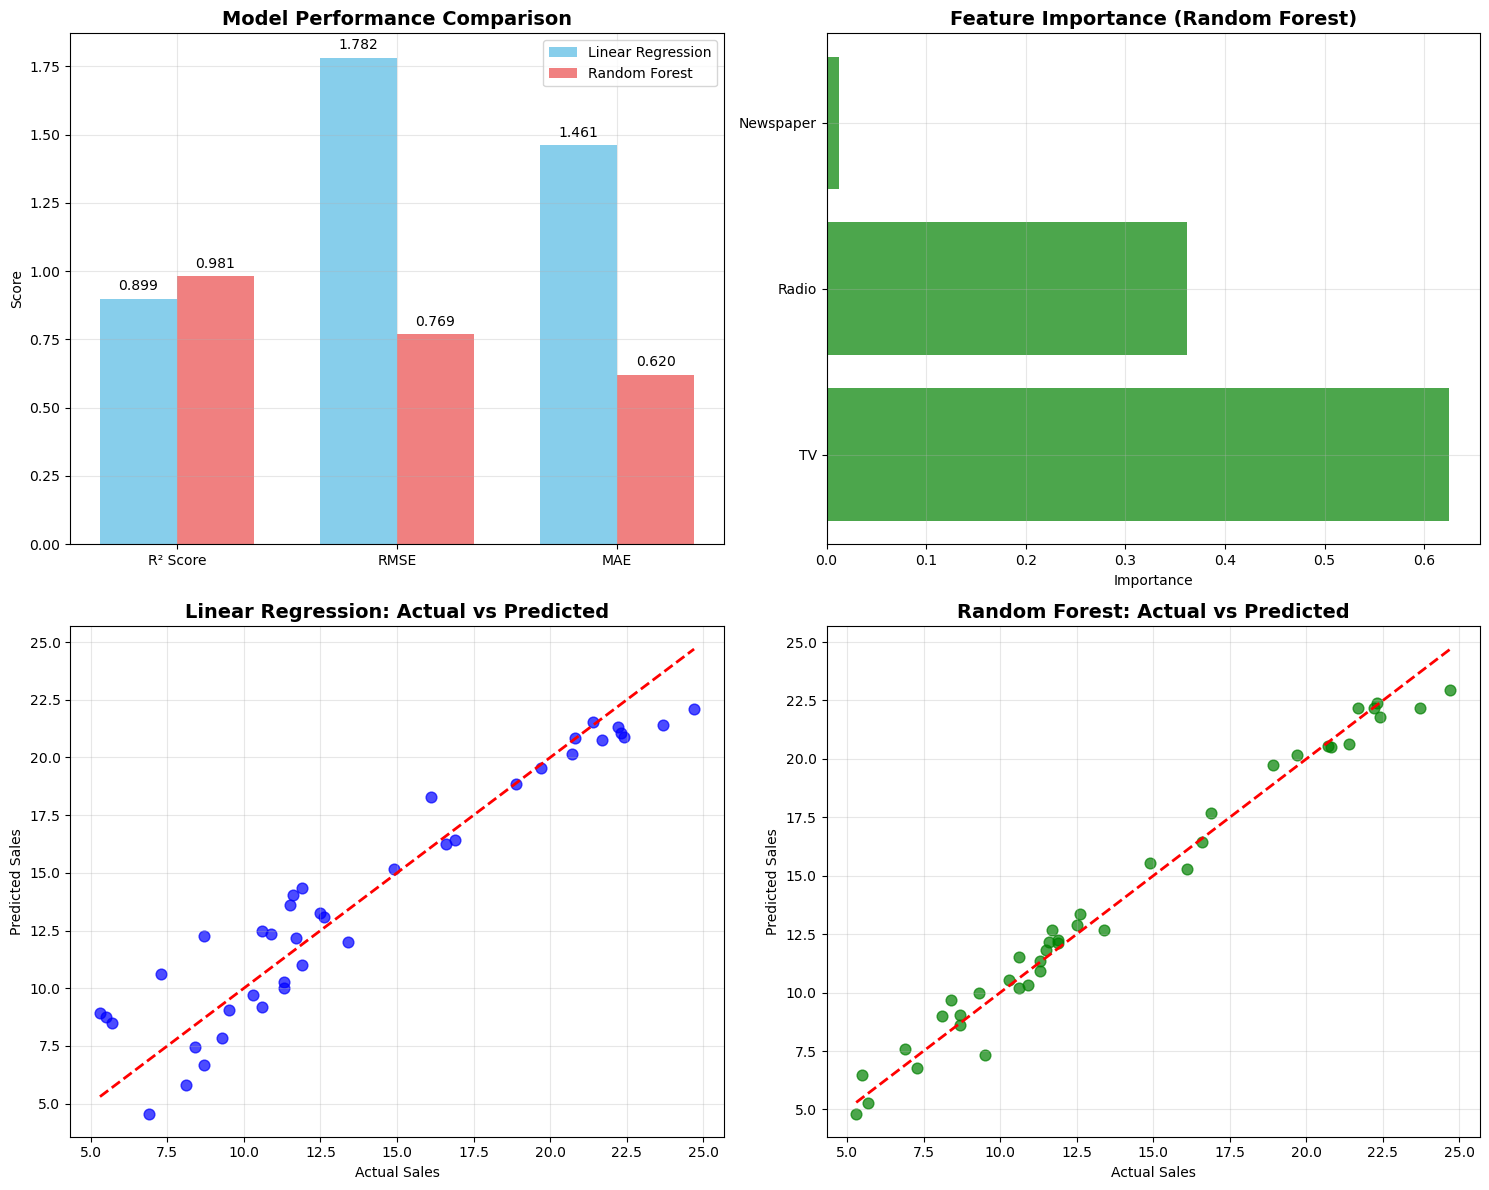

Model comparison visualizations saved!


In [17]:

# Create model comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Performance Comparison
metrics = ['R² Score', 'RMSE', 'MAE']
lr_values = [results['Linear Regression']['test_r2'], 
             results['Linear Regression']['test_rmse'],
             results['Linear Regression']['test_mae']]
rf_values = [results['Random Forest']['test_r2'], 
             results['Random Forest']['test_rmse'],
             results['Random Forest']['test_mae']]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, lr_values, width, label='Linear Regression', color='skyblue')
axes[0, 0].bar(x + width/2, rf_values, width, label='Random Forest', color='lightcoral')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(lr_values, rf_values)):
    axes[0, 0].text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom')
    axes[0, 0].text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom')

# 2. Feature Importance
axes[0, 1].barh(feature_importance['feature'], feature_importance['importance'], color='green', alpha=0.7)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Actual vs Predicted - Linear Regression
lr_pred = results['Linear Regression']['y_pred']
axes[1, 0].scatter(y_test, lr_pred, alpha=0.7, color='blue', s=60)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Sales')
axes[1, 0].set_ylabel('Predicted Sales')
axes[1, 0].set_title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted - Random Forest
rf_pred = results['Random Forest']['y_pred']
axes[1, 1].scatter(y_test, rf_pred, alpha=0.7, color='green', s=60)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Sales')
axes[1, 1].set_ylabel('Predicted Sales')
axes[1, 1].set_title('Random Forest: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/asabele/Downloads/Documents/My Data Science Practise/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model comparison visualizations saved!")


In [18]:

import joblib

# Save the best model (Random Forest)
best_model = results['Random Forest']['model']
joblib.dump(best_model, '/home/asabele/Downloads/Documents/My Data Science Practise/sales_prediction_model.pkl')

# Create a prediction function
def predict_sales(tv_budget, radio_budget, newspaper_budget):
    """
    Predict sales based on advertising budgets.
    
    Parameters:
    -----------
    tv_budget : float - TV advertising budget in thousands
    radio_budget : float - Radio advertising budget in thousands  
    newspaper_budget : float - Newspaper advertising budget in thousands
    
    Returns:
    --------
    predicted_sales : float - Predicted sales in thousands of units
    """
    input_data = np.array([[tv_budget, radio_budget, newspaper_budget]])
    prediction = best_model.predict(input_data)[0]
    return prediction

# Test the prediction function
test_cases = [
    (100, 20, 30),   # Medium budget
    (200, 40, 50),   # High budget
    (50, 10, 10),    # Low budget
    (0, 0, 0),       # No advertising
]

print("Sales Prediction Examples:\n")
print(f"{'TV':<10} {'Radio':<10} {'Newspaper':<12} {'Predicted Sales':<15}")
print("-" * 50)

for tv, radio, newspaper in test_cases:
    pred = predict_sales(tv, radio, newspaper)
    print(f"{tv:<10} {radio:<10} {newspaper:<12} {pred:<15.2f}")

# Model coefficients for Linear Regression (for interpretation)
lr_model = results['Linear Regression']['model']
print("Linear Regression Coefficients:")
print(f"Intercept: {lr_model.intercept_:.4f}")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.4f}")

print("Model saved as 'sales_prediction_model.pkl'")


Sales Prediction Examples:

TV         Radio      Newspaper    Predicted Sales
--------------------------------------------------
100        20         30           11.77          
200        40         50           20.26          
50         10         10           9.65           
0          0          0            2.97           


📊 Linear Regression Coefficients:
Intercept: 2.9791
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028
Model saved as 'sales_prediction_model.pkl'
